# Introduction à l'apprentissage machine

In [ ]:
!pip install scikit-learn
!pip install seaborn

In [1]:
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

**Cliquez sur le lien suivant pour télécharger les données**  
[Télécharger le fichier](https://filesender.renater.fr/?s=download&token=536b451d-ae15-406c-a5c6-bd13bd1d6096)

In [2]:
df_main = pd.read_csv('MAIN_CANON_1000.csv')

In [3]:
df_main.set_index("index", inplace = True)
df_main = df_main.replace(np.nan, 0)

In [4]:
df_main.canon.value_counts(normalize=True)

canon
non_canon    0.603716
canon        0.396284
Name: proportion, dtype: float64

In [5]:
def dated(df):
    df_res = df.copy()
    list_date = []
    for elem in df_res.index:
        list_date.append(int(elem.split('_')[0]))
    df_res['date'] = list_date
    return df_res

In [6]:
list(df_main.index)[0].split('_')[0]

'1811'

In [7]:
df_dated = dated(df_main)

In [8]:
def plot_decade_counts(df):
    # Create a new column for decades
    df['decade'] = (df['date'].values // 10) * 10

    # Group by decade and count 'canon' values
    decade_counts = df.groupby(['decade', 'canon']).size().unstack(fill_value=0)
    decade_counts.drop(2020, axis=0, inplace=True)

    fig, ax = plt.subplots(figsize=(30,15))
    decade_counts.plot(kind='bar', stacked=True, ax=ax, color=['r','b'])

    plt.xlabel('Decades', fontsize=30)
    plt.xticks(fontsize=30)
    plt.yticks(fontsize=30)
    plt.ylabel('Number of novels', fontsize=30)
    plt.legend(labels=['canon', 'corpus'], prop={'size': 30})

    plt.show()

    return decade_counts

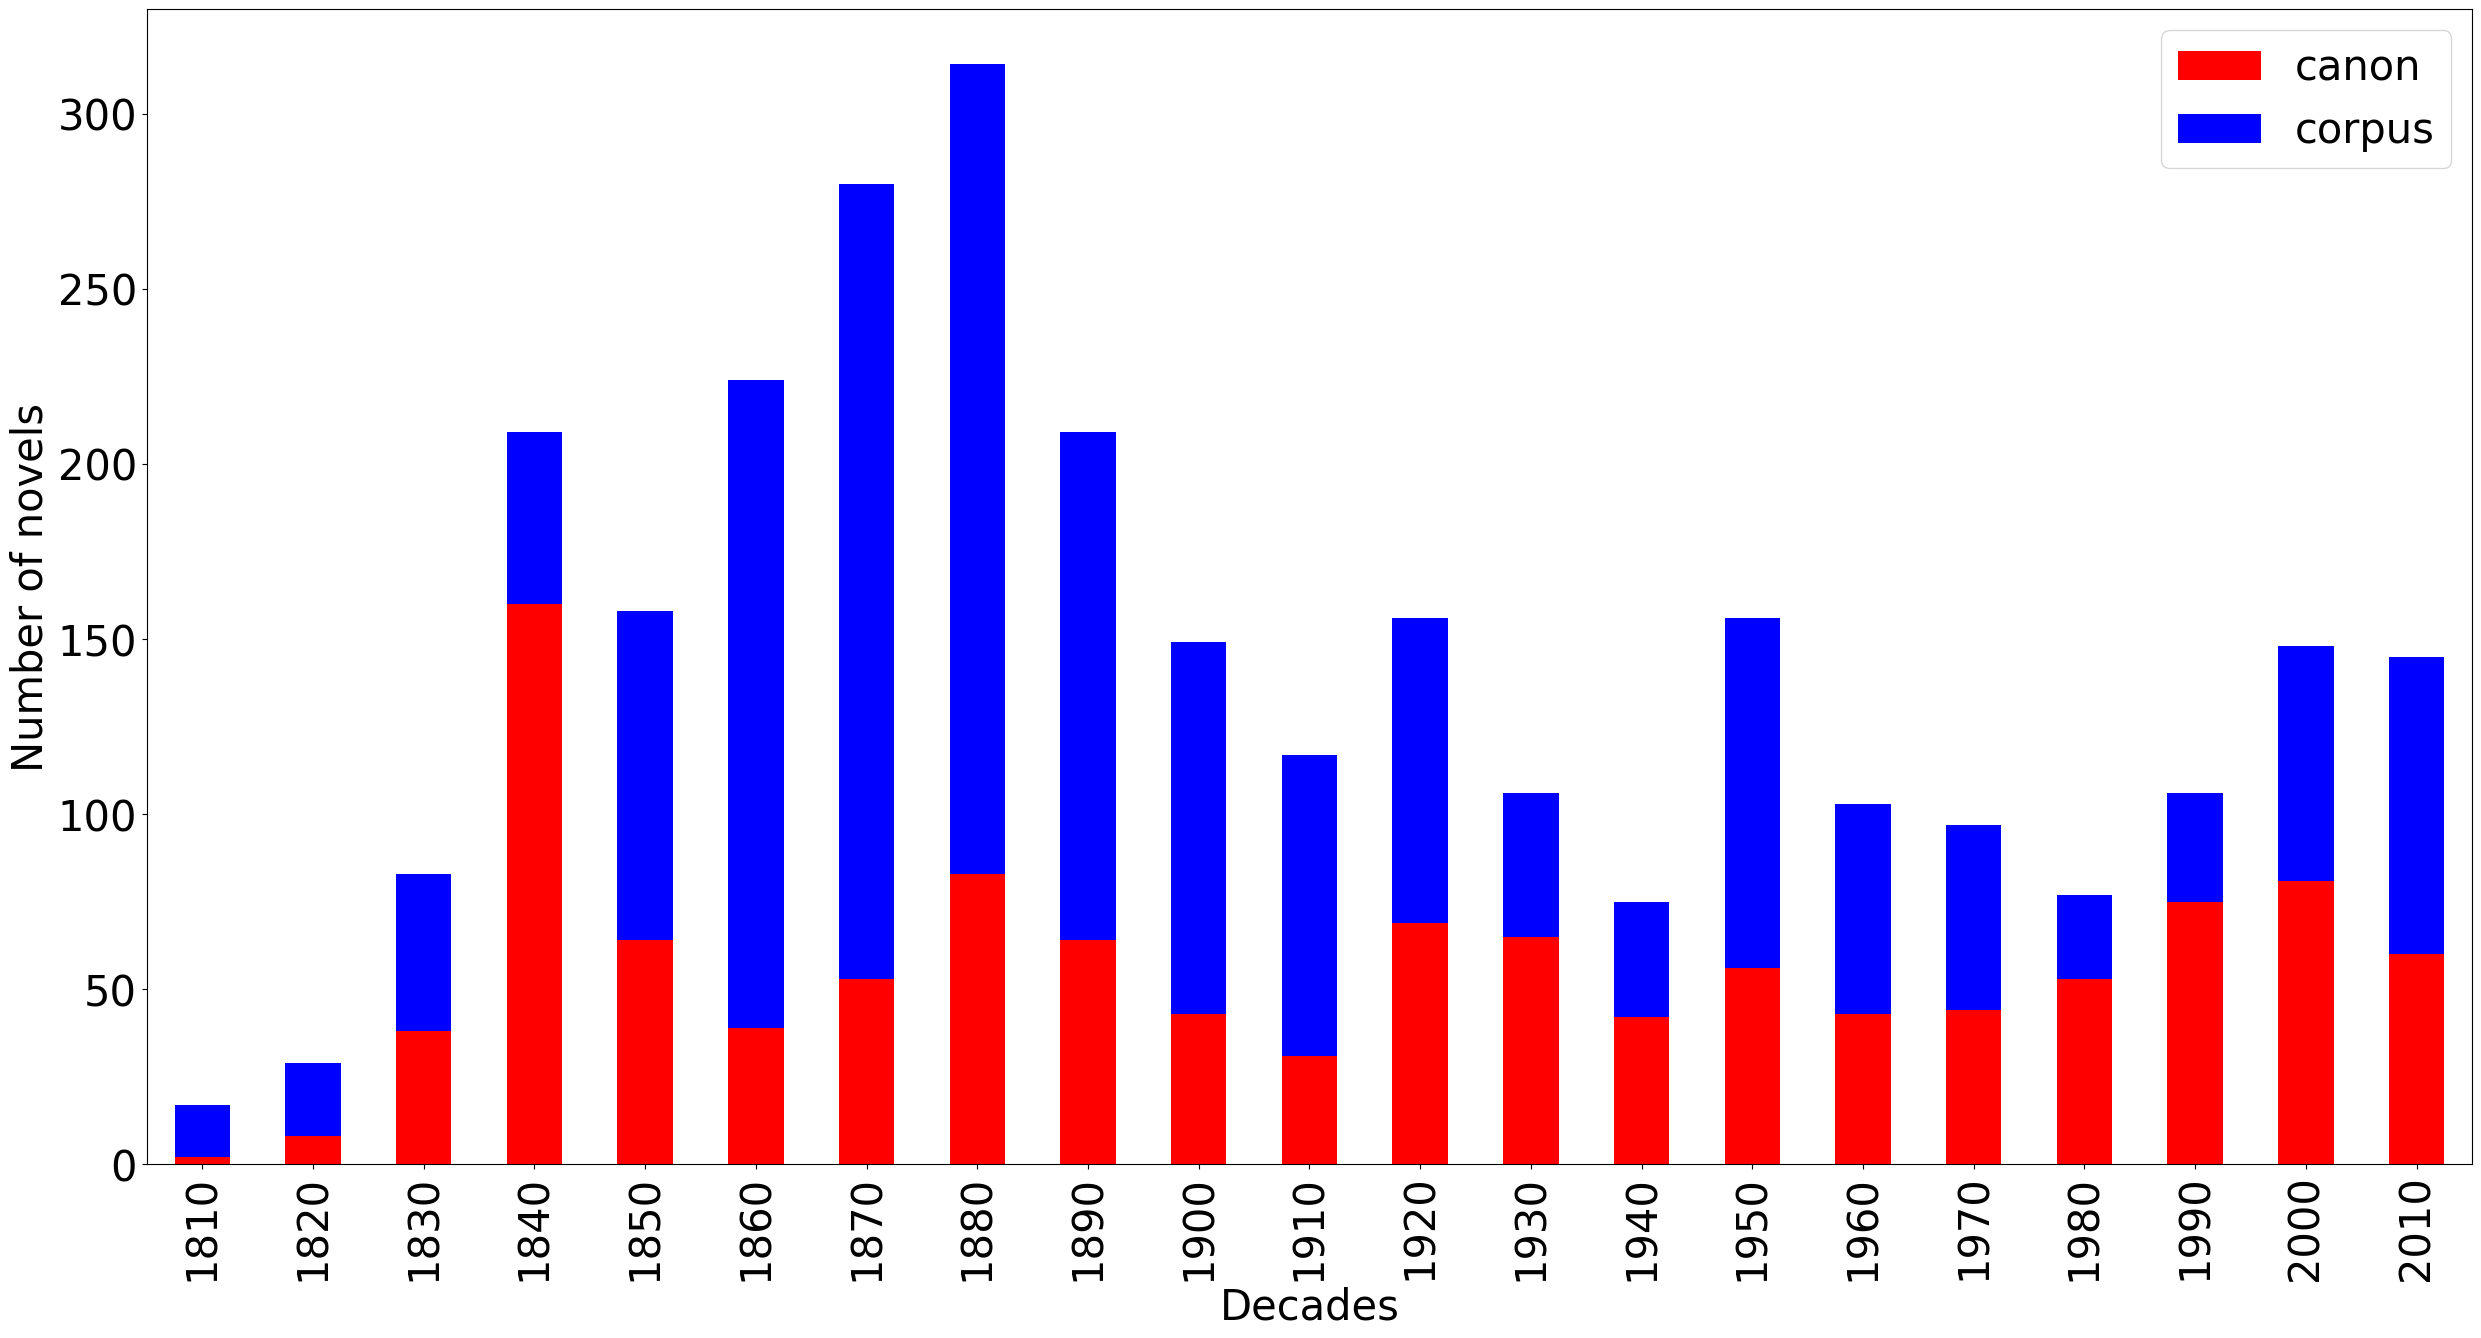

In [9]:
decade_counts_authors = plot_decade_counts(df_dated)

In [10]:
df_dated.drop('decade', axis=1, inplace=True)

In [11]:
from sklearn.model_selection import train_test_split

In [19]:
X = df_main.drop('canon', axis=1)
y = df_main['canon']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, r2_score, mean_absolute_error, mean_squared_error, ConfusionMatrixDisplay, classification_report

In [15]:
# Initialize the SVM model
svm = SVC()

# Train the model
svm.fit(X_train, y_train)

# Make predictions
y_pred_svm = svm.predict(X_test)

# Evaluate the model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {accuracy_svm:.2f}")

SVM Accuracy: 0.77


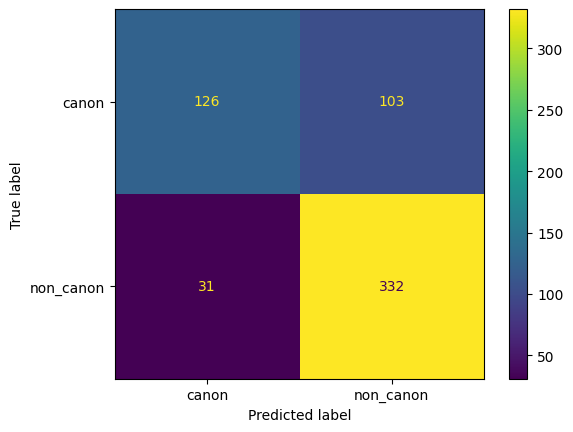

In [16]:
_ = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_svm)
report = classification_report(y_test, y_pred_svm, output_dict=True)
df_scores = pd.DataFrame(report).transpose().drop(['macro avg', 'weighted avg'])

In [17]:
df_scores

,precision,recall,f1-score,support
canon,0.802548,0.550218,0.652850,229.000000
non_canon,0.763218,0.914601,0.832080,363.000000
accuracy,0.773649,0.773649,0.773649,0.773649


In [21]:
scores_svm = cross_val_score(svm, X, y, cv=5)

In [22]:
scores_svm

array([0.63175676, 0.71790541, 0.7027027 , 0.69594595, 0.63006757])

# Datation de corpus

In [24]:
df_dated.drop(['canon'], axis=1, inplace=True)

In [25]:
type(list(df_dated.date)[0])

int

In [26]:
from sklearn.linear_model import ElasticNet
from sklearn.datasets import make_regression

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

In [28]:
#df_dated['decade'] = (df_dated['date'].values // 10) * 10
#df_dated

In [29]:
X_train, X_test, y_train, y_test = train_test_split(df_dated.drop('date', axis=1), df_dated['date'], test_size=0.2, random_state=42)

In [30]:
regr = LinearRegression()
regr.fit(X_train, y_train)

LinearRegression()

In [31]:
y_train

index
2014_Mathieu-Nicolas_Aux-animaux-la-guerre         2014
1863_Capendu-Ernest_Marcof-Le-Malouin              1863
1902_Laurie-Andre_Memoires-d-un-collegien-russe    1902
1925_Genevoix-Maurice_Raboliot                     1925
2019_Murail-Marie-Aude_Sauveur-Fils_5              2019
                                                   ... 
1908_Veuzit-Max-du_Le-mystere-de-Malbackt          1908
1882_Fleuriot-Zenaide_Bouche-en-coeur              1882
1883_Monnier-Marc_Un-detraque                      1883
1888_Mirbeau-Octave_L-Abbe-Jules                   1888
1876_Feuillet-Octave_Histoire-de-Sibylle           1876
Name: date, Length: 2368, dtype: int64

In [32]:
predicted_year = regr.predict(X_test)

In [33]:
mean_absolute_error(y_test, predicted_year)

14.170315549747999

In [34]:
df_plot = pd.DataFrame({'predicted_year': predicted_year, 'real_year': y_test})

In [35]:
import seaborn as sns

<Axes: xlabel='real_year', ylabel='predicted_year'>

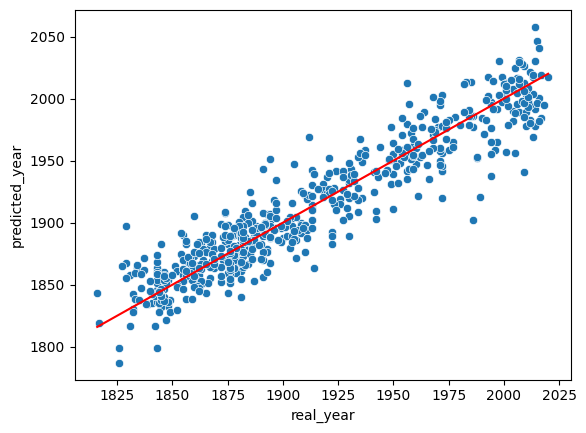

In [36]:
sns.scatterplot(data=df_plot, x='real_year', y='predicted_year')
sns.lineplot(data=df_plot, x='real_year', y='real_year', color='red')

In [37]:
df_plot['annees_erreur'] = abs(df_plot['real_year'] - df_plot['predicted_year'])

In [38]:
df_plot['decade'] = (df_plot['real_year'].values // 10) * 10

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21],
 [Text(0, 0, '1810'),
  Text(1, 0, '1820'),
  Text(2, 0, '1830'),
  Text(3, 0, '1840'),
  Text(4, 0, '1850'),
  Text(5, 0, '1860'),
  Text(6, 0, '1870'),
  Text(7, 0, '1880'),
  Text(8, 0, '1890'),
  Text(9, 0, '1900'),
  Text(10, 0, '1910'),
  Text(11, 0, '1920'),
  Text(12, 0, '1930'),
  Text(13, 0, '1940'),
  Text(14, 0, '1950'),
  Text(15, 0, '1960'),
  Text(16, 0, '1970'),
  Text(17, 0, '1980'),
  Text(18, 0, '1990'),
  Text(19, 0, '2000'),
  Text(20, 0, '2010'),
  Text(21, 0, '2020')])

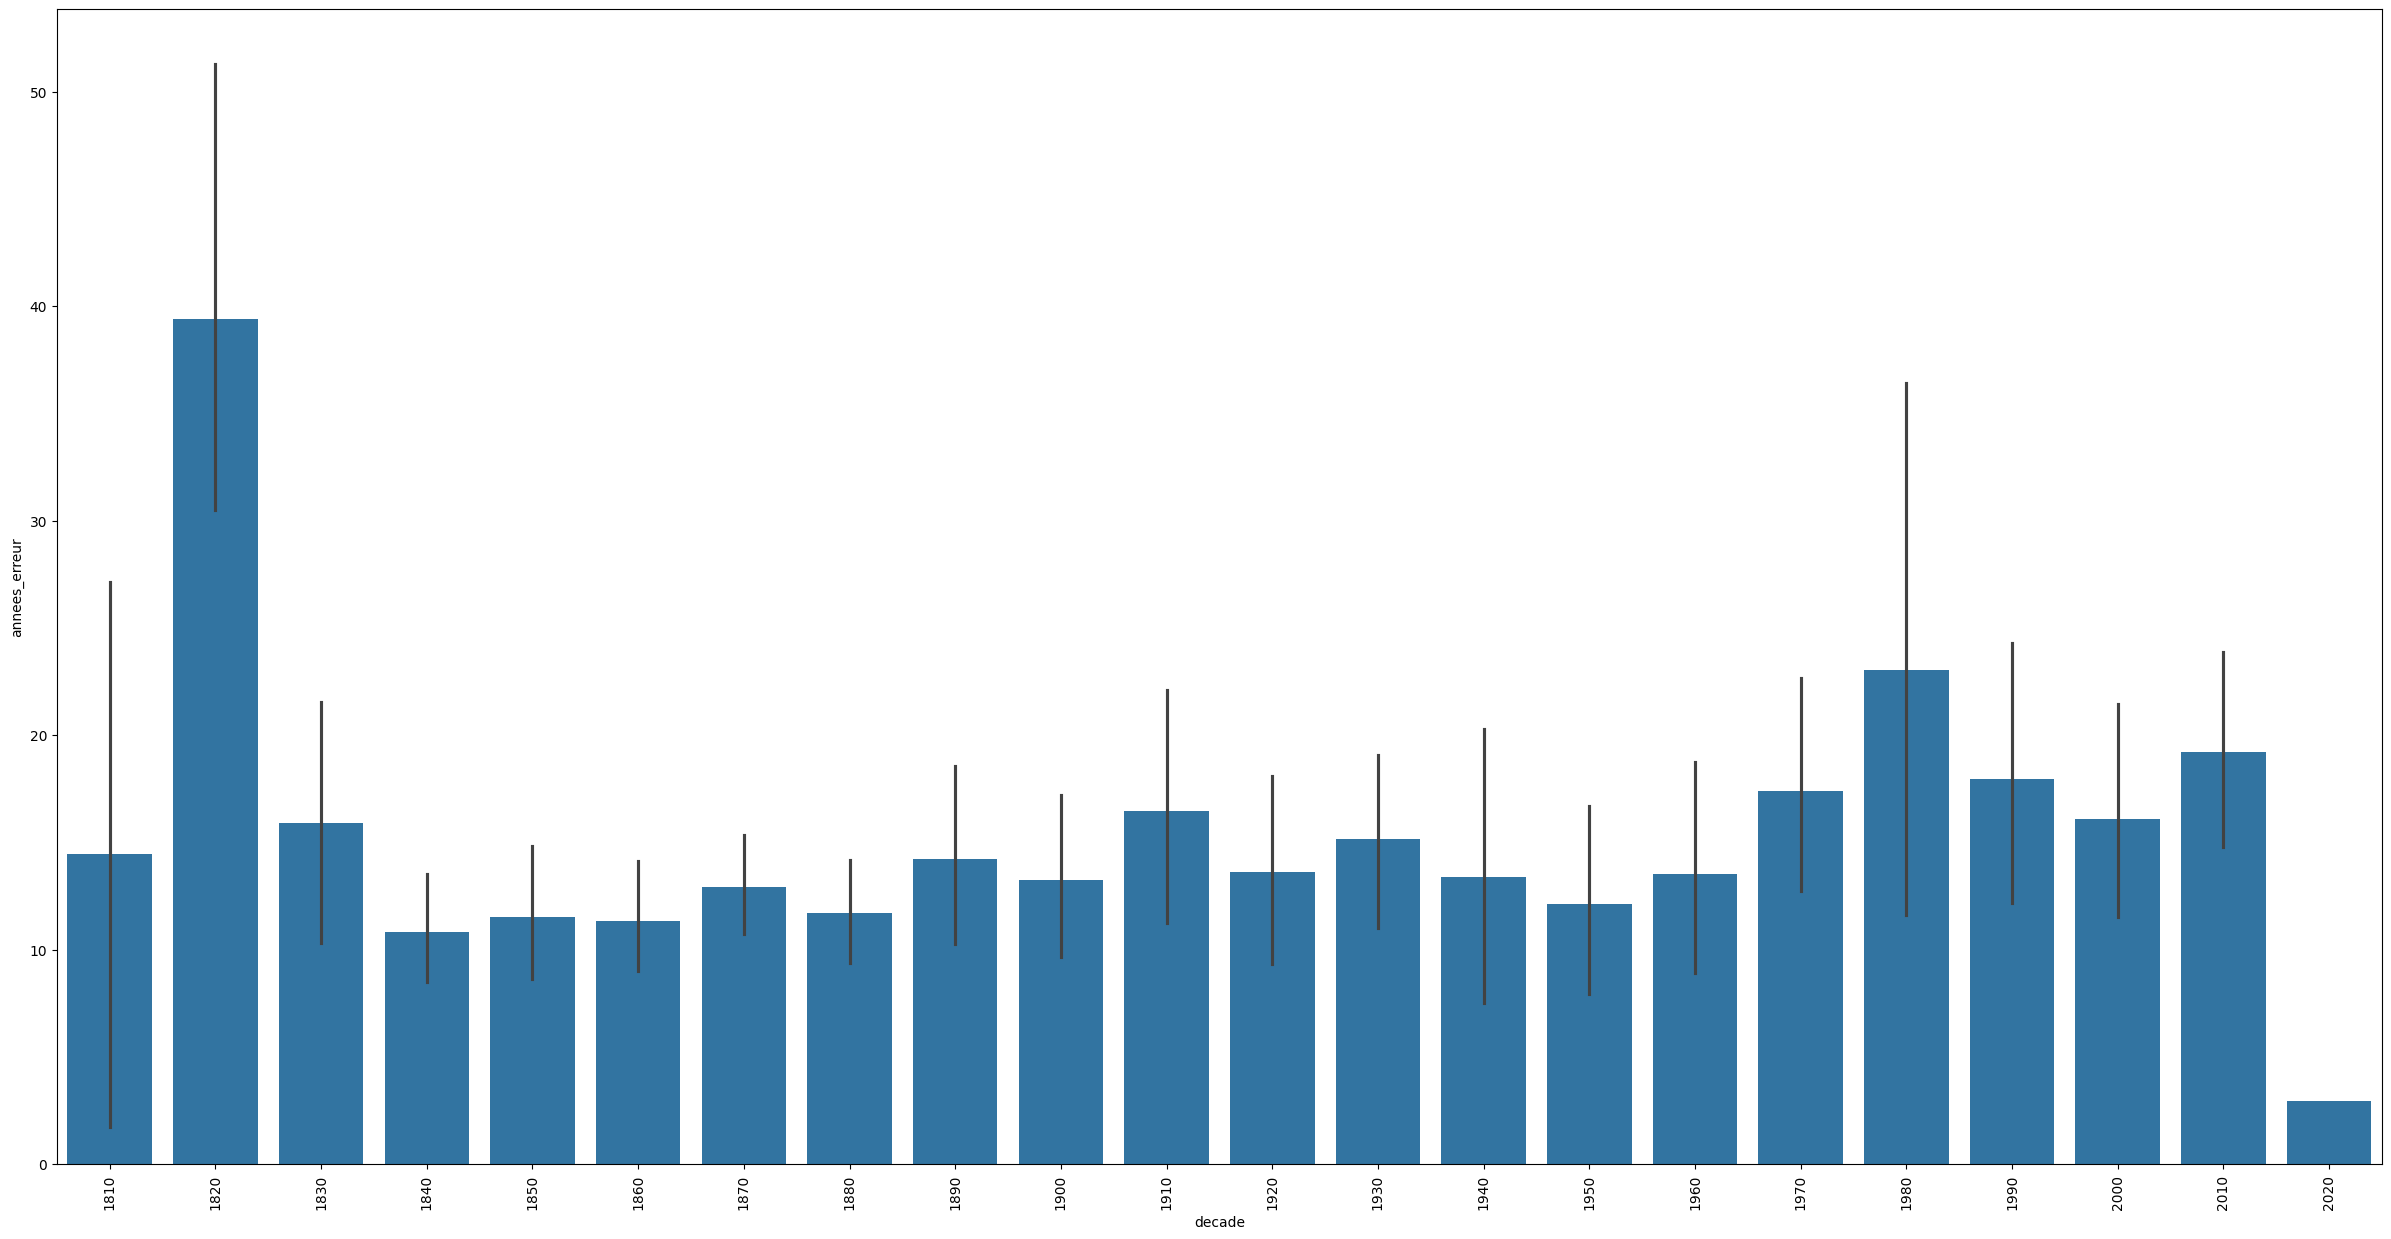

In [39]:
ax, fig = plt.subplots(figsize=(30,15))
sns.barplot(data=df_plot, x='decade', y='annees_erreur')
plt.xticks(rotation = 90)